In [ ]:
!pip install pymeshit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 336.1/336.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.1/572.1 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.1/175.1 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 272.2/272.2 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 115.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.5/134.5 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.1/411.1 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.1/230.1 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.0/95.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
import Pymeshit

In [ ]:
from google.colab import files
from pathlib import Path
uploaded = files.upload()
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
for filename, content in uploaded.items():
     (DATA_DIR / filename).write_bytes(content)

print("Data folder:", DATA_DIR.resolve())
print("Files:")
for path in sorted(DATA_DIR.glob("*")):
    print(" -", path.name)

Saving border1.txt to border1 (3).txt
Saving border2.txt to border2 (3).txt
Saving border3.txt to border3 (3).txt
Saving border4.txt to border4 (3).txt
Saving bottom.dat to bottom (3).dat
Saving fault1.txt to fault1 (3).txt
Saving fault2.txt to fault2 (3).txt
Saving middle.dat to middle (3).dat
Saving top.dat to top (3).dat
Data folder: /content/data
Files:
 - border1 (3).txt
 - border2 (3).txt
 - border3 (3).txt
 - border4 (3).txt
 - bottom (3).dat
 - fault1 (3).txt
 - fault2 (3).txt
 - middle (3).dat
 - top (3).dat


In [ ]:
# Example input using examples/data.
# Updated to match the filenames actually present in /content/data
from Pymeshit.headless import (
        MeshCase,
        MeshOptions,
        SurfaceSpec,
        WellSpec,
        MaterialSpec,
        read_points,
        run_mesh_case,
)
surface_groups = [
    {
        "role": "border",
        "target_size": 15.0,
        "files": [
            "bottom (3).dat",
            "top (3).dat",
            "border1 (3).txt",
            "border2 (3).txt",
            "border3 (3).txt",
            "border4 (3).txt",
        ],
    },
    {
        "role": "unit",
        "target_size": 15.0,
        "files": [
            "middle (3).dat",
        ],
    },
    {
        "role": "fault",
        "target_size": 15.0,
        "files": [
            "fault1 (3).txt",
            "fault2 (3).txt",
        ],
    },
]

def build_surfaces_from_groups(surface_groups, data_dir: Path):
    surfaces = []
    for group in surface_groups:
        role = group["role"]
        target_size = float(group.get("target_size", 15.0))
        for filename in group["files"]:
            path = data_dir / filename
            if not path.exists():
                print(f"WARNING: missing {path}. Edit surface_groups or upload the file.")
                continue
            # Note: Ensure read_points and SurfaceSpec are defined in your environment
            pts = read_points(path)
            name = path.stem
            print(f"{name:20s} role={role:7s} target={target_size:6.2f} points={len(pts):5d} path={path}")
            surfaces.append(SurfaceSpec(name=name, points=pts, role=role, target_size=target_size))
    return surfaces

surfaces = build_surfaces_from_groups(surface_groups, DATA_DIR)
print("Loaded surfaces:", len(surfaces))

bottom (3)           role=border  target= 15.00 points=  441 path=data/bottom (3).dat
top (3)              role=border  target= 15.00 points=  441 path=data/top (3).dat
border1 (3)          role=border  target= 15.00 points=    4 path=data/border1 (3).txt
border2 (3)          role=border  target= 15.00 points=    4 path=data/border2 (3).txt
border3 (3)          role=border  target= 15.00 points=    4 path=data/border3 (3).txt
border4 (3)          role=border  target= 15.00 points=    4 path=data/border4 (3).txt
middle (3)           role=unit    target= 15.00 points=  441 path=data/middle (3).dat
fault1 (3)           role=fault   target= 15.00 points=    4 path=data/fault1 (3).txt
fault2 (3)           role=fault   target= 15.00 points=    4 path=data/fault2 (3).txt
Loaded surfaces: 9


In [ ]:
well_inputs = [
    # name, filename, target_size
    # ("well_1", "well_1.txt", 20.0),
]

wells = []
for name, filename, target_size in well_inputs:
    path = DATA_DIR / filename
    if not path.exists():
        print(f"WARNING: missing {path}. Edit well_inputs or upload the file.")
        continue
    pts = read_points(path)
    print(f"{name:20s} points={len(pts)} path={path}")
    wells.append(WellSpec(name=name, points=pts, target_size=target_size))

print("Loaded wells:", len(wells))

Loaded wells: 0


In [ ]:
# Example material seed points for examples/data.
# Put each seed inside the volume region it should label.
# With middle.dat near z=0, these two seeds label lower and upper domains.
materials = [
    MaterialSpec("lower_unit", [0.0, 0.0, -25.0], attribute=1),
    MaterialSpec("upper_unit", [0.0, 0.0, 25.0], attribute=2),
]

for material in materials:
    print(material)


MaterialSpec(name='lower_unit', locations=[0.0, 0.0, -25.0], attribute=1, type='FORMATION', max_volume=0.0)
MaterialSpec(name='upper_unit', locations=[0.0, 0.0, 25.0], attribute=2, type='FORMATION', max_volume=0.0)


In [ ]:
if not surfaces:
    raise RuntimeError("No surfaces loaded. Upload files and edit surface_groups first.")

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

options = MeshOptions(
    target_size=15.0,
    min_angle=20.0,
    gradient=2.0,
    hull_method="delaunay",
    interpolation="Thin Plate Spline (TPS)",
    smoothing=0.0,
    constraint_mode="intersections",
    preserve_boundary_hulls=True,
    include_hull_fallback_faults_in_volume=False,
    tetgen_switches="pq1.414aAY",
    generate_volume=True,
)

case = MeshCase(
    surfaces=surfaces,
    wells=wells,
    materials=materials,
    options=options,
)

result = run_mesh_case(case, output_path=OUTPUT_DIR / "example_data_case.exo")
if result.tetra_mesh is not None:
    result.export_mesh(OUTPUT_DIR / "example_data_case.vtu")

print("Failures:", result.failures)
if result.tetra_mesh is not None:
    print("Tetra mesh points:", result.tetra_mesh.n_points)
    print("Tetra mesh cells:", result.tetra_mesh.n_cells)
    print("Saved Exodus:", (OUTPUT_DIR / "example_data_case.exo").resolve())
    print("Saved VTU:", (OUTPUT_DIR / "example_data_case.vtu").resolve())
else:
    print("No tetra mesh was generated. Check failures and logs above.")

Failures: []
Tetra mesh points: 1944
Tetra mesh cells: 8470
Saved Exodus: /content/outputs/example_data_case.exo
Saved VTU: /content/outputs/example_data_case.vtu


/tmp/ipykernel_1026/944015362.py:4: UserWarning: Using static image for notebook display.
Install trame for interactive backends: pip install "pyvista[jupyter]"
  result.tetra_mesh.plot(scalars=scalars, show_edges=True)


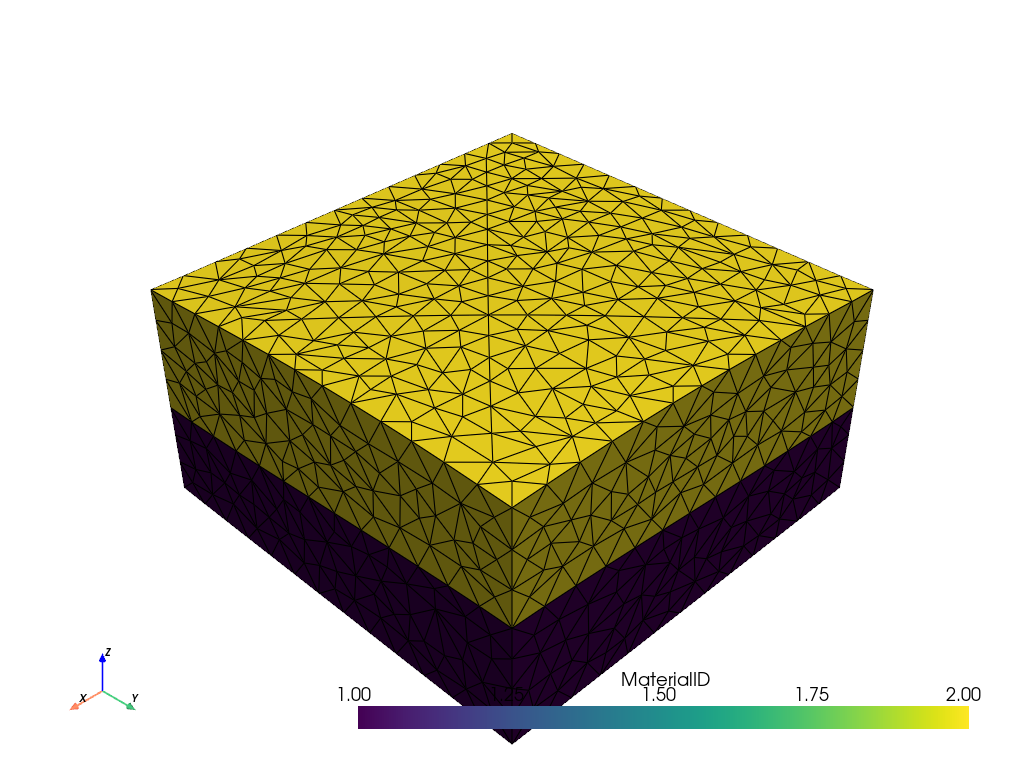

In [ ]:
import pyvista as pv
if result.tetra_mesh is not None:
     scalars = "MaterialID" if "MaterialID" in result.tetra_mesh.cell_data else None
     result.tetra_mesh.plot(scalars=scalars, show_edges=True)